In [220]:
#Import Libraries

In [221]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [222]:
#Load Dataset

In [223]:
# Load restaurant transaction dataset

df = pd.read_excel(
    "Restaurant_Chain_Feature_Store.xlsx"
)

# Display first 5 records
df.head()

,Transaction_ID,Customer_ID,Customer_Name,Branch_ID,Date,Time,Hour,Day_of_Week,Month,Item_Name,Quantity,Total_Amount,Peak_Hour_Flag,Daily_Sales_Amount,Weekend_Sales_Amount,Item_Velocity,Branch_Seasonality,Customer_Purchase_Count,Average_Order_Value
0,TX00001,C037,Ayesha,B08,2025-05-14,21:00,21,Wednesday,May,Fries,7,4263,0,4263,0,14,1.1,14,2131.50
1,TX00002,C005,Sameer,B06,2025-01-31,15:00,15,Friday,January,Fries,2,840,0,840,0,4,1.2,12,280.00
2,TX00003,C025,Ali,B08,2025-04-09,13:00,13,Wednesday,April,Fries,3,1215,1,1215,0,6,1.2,9,405.00
3,TX00004,C039,Ahmed,B08,2025-02-27,16:00,16,Thursday,February,Pizza,2,2132,0,2132,0,4,1.0,10,1066.00
4,TX00005,C006,Ahmed,B01,2025-01-10,17:00,17,Friday,January,Coffee,4,1856,0,1856,0,8,1.2,12,618.67


In [224]:
#Dataset Overview

In [225]:
# Check number of rows and columns

print(df.shape)

# View column names and data types

df.info()

(200, 19)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Transaction_ID           200 non-null    str    
 1   Customer_ID              200 non-null    str    
 2   Customer_Name            200 non-null    str    
 3   Branch_ID                200 non-null    str    
 4   Date                     200 non-null    str    
 5   Time                     200 non-null    str    
 6   Hour                     200 non-null    int64  
 7   Day_of_Week              200 non-null    str    
 8   Month                    200 non-null    str    
 9   Item_Name                200 non-null    str    
 10  Quantity                 200 non-null    int64  
 11  Total_Amount             200 non-null    int64  
 12  Peak_Hour_Flag           200 non-null    int64  
 13  Daily_Sales_Amount       200 non-null    int64  
 14  Weekend_Sales_Amount     20

In [226]:
#Missing Values

In [227]:
# Check missing values in each column

df.isnull().sum()

Transaction_ID             0
Customer_ID                0
Customer_Name              0
Branch_ID                  0
Date                       0
Time                       0
Hour                       0
Day_of_Week                0
Month                      0
Item_Name                  0
Quantity                   0
Total_Amount               0
Peak_Hour_Flag             0
Daily_Sales_Amount         0
Weekend_Sales_Amount       0
Item_Velocity              0
Branch_Seasonality         0
Customer_Purchase_Count    0
Average_Order_Value        0
dtype: int64

In [228]:
#Data Cleaning

In [229]:
# Remove duplicate records

df.drop_duplicates(inplace=True)

# Replace missing values with 0

df.fillna(0, inplace=True)

print("Data Cleaned Successfully")

Data Cleaned Successfully


In [230]:
#Feature Engineering Section

In [231]:
#Peak Hour Flag

In [232]:
# Top performing hours identified from sales analysis

peak_hours = [20, 8, 22, 15, 13]

# Create binary peak hour indicator

df["Peak_Hour_Flag"] = (
    df["Hour"]
    .isin(peak_hours)
    .astype(int)
)

df[
    [
        "Transaction_ID",
        "Hour",
        "Peak_Hour_Flag"
    ]
].head()

,Transaction_ID,Hour,Peak_Hour_Flag
0,TX00001,21,0
1,TX00002,15,1
2,TX00003,13,1
3,TX00004,16,0
4,TX00005,17,0


In [233]:
#Weekend Flag

In [234]:
# Identify weekend transactions

df["Weekend_Flag"] = np.where(
    df["Day_of_Week"].isin(
        ["Saturday","Sunday"]
    ),
    1,
    0
)

In [235]:
#Weekend Uplift

In [236]:
# Store sales amount only for weekend transactions

df["Weekend_Sales_Amount"] = np.where(
    df["Weekend_Flag"] == 1,
    df["Total_Amount"],
    0
)

In [237]:
#Item Velocity

In [238]:
# Calculate total quantity sold for each item

item_velocity = (
    df.groupby("Item_Name")
      ["Quantity"]
      .sum()
)

# Map quantity sold back to dataset

df["Item_Velocity"] = (
    df["Item_Name"]
      .map(item_velocity)
)

In [239]:
#Customer Purchase Count

In [240]:
# Count number of purchases per customer

purchase_count = (
    df.groupby("Customer_ID")
      .size()
)

df["Customer_Purchase_Count"] = (
    df["Customer_ID"]
      .map(purchase_count)
)

In [241]:
 #Average Order Value

In [242]:
# Calculate average spending per customer

avg_order = (
    df.groupby("Customer_ID")
      ["Total_Amount"]
      .mean()
)

df["Average_Order_Value"] = (
    df["Customer_ID"]
      .map(avg_order)
)

In [243]:
#Branch Seasonality

In [244]:
# Calculate average monthly sales per branch

seasonality = (
    df.groupby(
        ["Branch_ID", "Month"]
    )["Total_Amount"]
    .mean()
)

# Assign seasonality value

df["Branch_Seasonality"] = (
    df.set_index(
        ["Branch_ID", "Month"]
    ).index.map(seasonality)
)

In [245]:
#Feature Store

In [246]:
# Create final feature store

feature_store = df[
    [
        "Transaction_ID",
        "Customer_ID",
        "Peak_Hour_Flag",
        "Weekend_Sales_Amount",
        "Item_Velocity",
        "Branch_Seasonality",
        "Customer_Purchase_Count",
        "Average_Order_Value"
    ]
]

feature_store.head()

,Transaction_ID,Customer_ID,Peak_Hour_Flag,Weekend_Sales_Amount,Item_Velocity,Branch_Seasonality,Customer_Purchase_Count,Average_Order_Value
0,TX00001,C037,0,0,179,3948.333333,2,4837.000000
1,TX00002,C005,1,0,179,1581.600000,3,4913.666667
2,TX00003,C025,1,0,179,1573.500000,5,3181.800000
3,TX00004,C039,0,0,152,3690.000000,5,3212.000000
4,TX00005,C006,0,0,217,3447.333333,5,3731.400000


In [247]:
#KPI Summary

In [248]:
# Business KPIs

print(
    "Total Revenue:",
    df["Total_Amount"].sum()
)

print(
    "Total Transactions:",
    len(df)
)

print(
    "Average Order Value:",
    round(
        df["Total_Amount"].mean(),
        2
    )
)

Total Revenue: 802309
Total Transactions: 200
Average Order Value: 4011.54


In [249]:
#Peak Hour Analysis

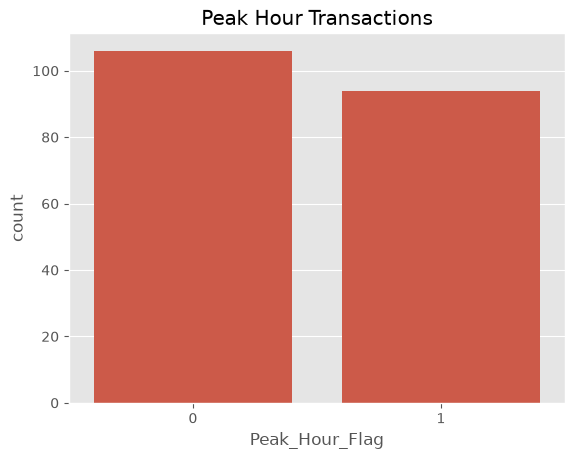

In [250]:
# Visualize peak vs non-peak transactions

sns.countplot(
    x="Peak_Hour_Flag",
    data=df
)

plt.title(
    "Peak Hour Transactions"
)

plt.show()

In [251]:
#Weekend Analysis

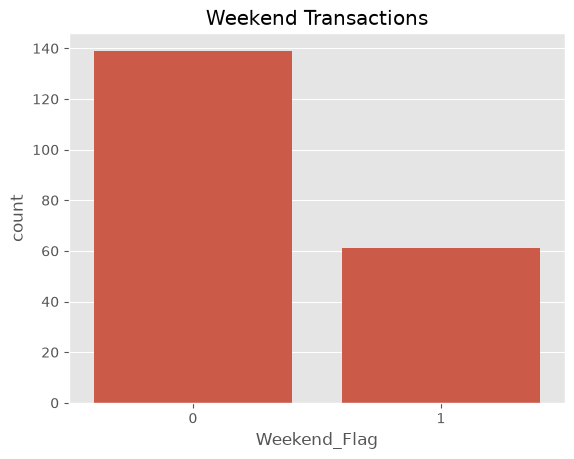

In [252]:
# Compare weekday and weekend transactions

sns.countplot(
    x="Weekend_Flag",
    data=df
)

plt.title(
    "Weekend Transactions"
)

plt.show()

In [253]:
#Top Selling Items

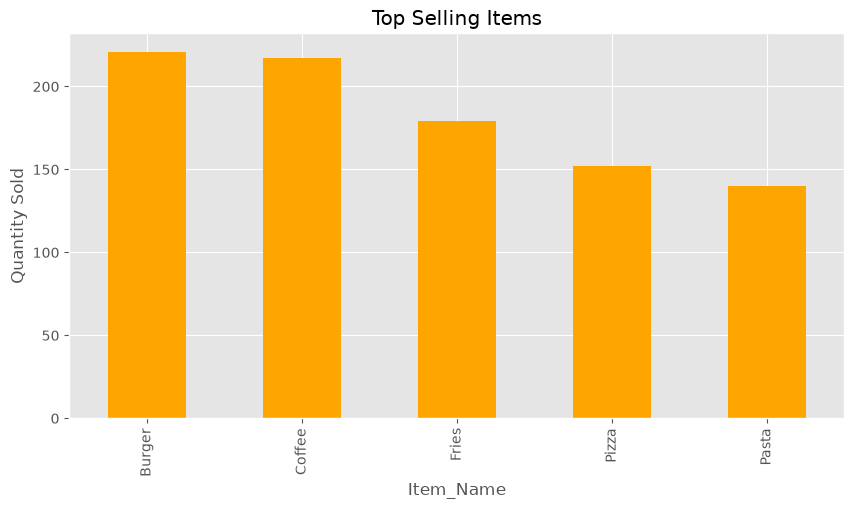

In [254]:
# Identify best-selling menu items

top_items = (
    df.groupby("Item_Name")
      ["Quantity"]
      .sum()
      .sort_values(
          ascending=False
      )
)

top_items.plot(
    kind="bar",
    figsize=(10,5),
    color="orange"
)

plt.title(
    "Top Selling Items"
)

plt.ylabel(
    "Quantity Sold"
)

plt.show()

In [255]:
#Revenue by Hour

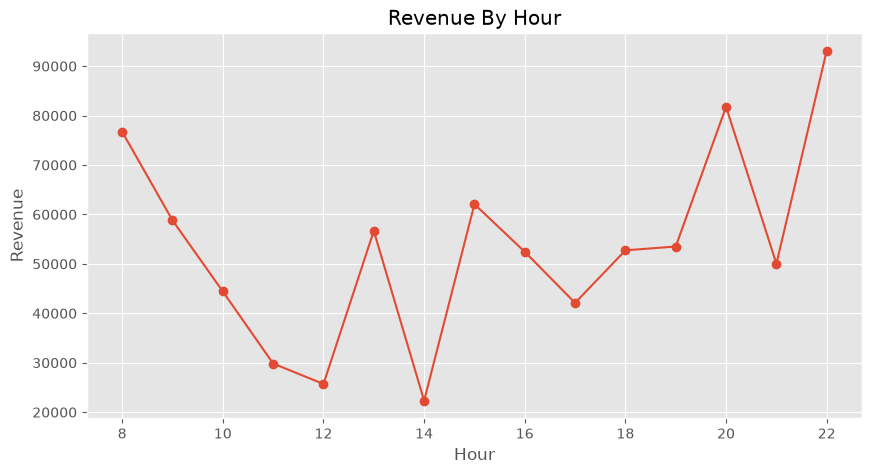

In [256]:
# Analyze hourly revenue trend

hourly_sales = (
    df.groupby("Hour")
      ["Total_Amount"]
      .sum()
)

hourly_sales.plot(
    figsize=(10,5),
    marker="o"
)

plt.title(
    "Revenue By Hour"
)

plt.ylabel(
    "Revenue"
)

plt.show()

In [257]:
#Export Feature Store

In [258]:
# Save engineered features into Excel

feature_store.to_excel(
    "Restaurant_Feature_Store_Output.xlsx",
    index=False
)

print(
    "Feature Store Saved Successfully!"
)

Feature Store Saved Successfully!
